In [42]:
import pandas as pd
from srai.regionalizers import H3Regionalizer, geocode_to_region_gdf
from srai.embedders import CountEmbedder
from srai.joiners import IntersectionJoiner
from srai.loaders import OSMOnlineLoader

#### Wczytanie mapy Wrocławia i podzielenie obszaru na heksagony.

In [43]:
area = geocode_to_region_gdf("Wrocław, Poland")
regionalizer = H3Regionalizer(resolution=8) # https://h3geo.org/docs/core-library/restable/
regions = regionalizer.transform(area)
regions.head()

,geometry
region_id,
881e2040d5fffff,"POLYGON ((17.02956 51.11266, 17.03465 51.10945..."
881e20454dfffff,"POLYGON ((17.09252 51.10189, 17.09494 51.10617..."
881e204521fffff,"POLYGON ((17.09832 51.06333, 17.10582 51.06439..."
881e20415dfffff,"POLYGON ((16.86935 51.09769, 16.87444 51.09448..."
881e20452dfffff,"POLYGON ((17.08308 51.07299, 17.08066 51.06871..."


Ściągnięcie dla Wrocławia danych o:
- sygnalizacji świetlnej,
- skrzyżowaniach,
- chodnikach,
- progach zwalniających,
- lampach ulicznych,
- drogach dla rowerów.

In [44]:
from srai.plotting import plot_regions

query = {"traffic_signals" : {"highway": "traffic_signals"},
         "crossing" : {"highway": "crossing"},
         "sidewalk" : {"footway":"sidewalk"},
         "traffic_calming" : {"traffic_calming":"yes"},
         "street_lamp" : {"highway": "street_lamp"},
         "bicycle_road" : {"bicycle_road": "yes"}
}
area = geocode_to_region_gdf("Wrocław, Poland")
loader = OSMOnlineLoader()

feature_gdf = loader.load(area, query)
feature_gdf.head()

Grouping features: 100%|██████████| 12617/12617 [00:00<00:00, 19346.04it/s]


,geometry,traffic_signals,crossing,sidewalk,traffic_calming,street_lamp,bicycle_road
feature_id,,,,,,,
node/150597406,POINT (16.97786 51.09238),NaN,highway=crossing,NaN,NaN,NaN,NaN
node/151334674,POINT (16.97939 51.09485),highway=traffic_signals,NaN,NaN,NaN,NaN,NaN
node/153568043,POINT (16.96694 51.07828),NaN,highway=crossing,NaN,NaN,NaN,NaN
node/158719856,POINT (17.03100 51.09441),NaN,highway=crossing,NaN,NaN,NaN,NaN
node/158719876,POINT (17.04118 51.09612),highway=traffic_signals,NaN,NaN,NaN,NaN,NaN


#### Zliczenie ile jest w danym heksagonie sygnalizacji świetlnej, skrzyżowań itd. (nasze X).

In [45]:
regions = regionalizer.transform(area)
joiner = IntersectionJoiner()
joint_features = joiner.transform(regions, feature_gdf)
embedder = CountEmbedder()
embeddings = embedder.transform(regions, feature_gdf, joint_features)
embeddings_feature_gdf = pd.merge(regions, embeddings, on='region_id', how='inner')
embeddings_feature_gdf.head()

,geometry,traffic_signals_highway=traffic_signals,crossing_highway=crossing,sidewalk_footway=sidewalk,traffic_calming_traffic_calming=yes,street_lamp_highway=street_lamp,bicycle_road_bicycle_road=yes
region_id,,,,,,,
881e2040d5fffff,"POLYGON ((17.02956 51.11266, 17.03465 51.10945...",25,80,14,0,148,0
881e20454dfffff,"POLYGON ((17.09252 51.10189, 17.09494 51.10617...",4,29,3,0,0,0
881e204521fffff,"POLYGON ((17.09832 51.06333, 17.10582 51.06439...",0,1,3,0,0,0
881e20415dfffff,"POLYGON ((16.86935 51.09769, 16.87444 51.09448...",0,0,0,0,0,0
881e20452dfffff,"POLYGON ((17.08308 51.07299, 17.08066 51.06871...",0,7,7,0,0,0


#### Wczytanie informacji ile wypadków było w danym heksagonie w roku 2023 (nasze Y).

In [46]:
df_accidents = pd.read_csv('data/embeddings.csv')
# df_accidents = pd.read_csv('embeddings.csv')
df_accidents.head()

,region_id,rok_2023
0,881e204059fffff,14
1,881e205561fffff,0
2,881e2041ddfffff,3
3,881e204225fffff,10
4,881e2050a1fffff,0


Połącznie tabeli z X z tabelą z Y.

In [47]:
gdf = pd.merge(embeddings_feature_gdf, df_accidents, on='region_id', how='inner')
gdf.head()

,region_id,geometry,traffic_signals_highway=traffic_signals,crossing_highway=crossing,sidewalk_footway=sidewalk,traffic_calming_traffic_calming=yes,street_lamp_highway=street_lamp,bicycle_road_bicycle_road=yes,rok_2023
0,881e2040d5fffff,"POLYGON ((17.02956 51.11266, 17.03465 51.10945...",25,80,14,0,148,0,63
1,881e20454dfffff,"POLYGON ((17.09252 51.10189, 17.09494 51.10617...",4,29,3,0,0,0,12
2,881e204521fffff,"POLYGON ((17.09832 51.06333, 17.10582 51.06439...",0,1,3,0,0,0,4
3,881e20415dfffff,"POLYGON ((16.86935 51.09769, 16.87444 51.09448...",0,0,0,0,0,0,0
4,881e20452dfffff,"POLYGON ((17.08308 51.07299, 17.08066 51.06871...",0,7,7,0,0,0,10


#### Dodanie kolumny mówiącej o poziomie ryzyka w danym obszarze w zależości od liczby wpadków.

In [48]:
bins = [-1, 0, 2, 12, float("inf")]  # Bins: (-1, 0], (0, 3], (3, 10], (10, inf)
label_names = ['no risk', 'low risk', 'medium risk', 'high risk']
gdf['risk_level'] = pd.cut(gdf['rok_2023'], bins=bins, labels=label_names, right=True)
gdf.head()

,region_id,geometry,traffic_signals_highway=traffic_signals,crossing_highway=crossing,sidewalk_footway=sidewalk,traffic_calming_traffic_calming=yes,street_lamp_highway=street_lamp,bicycle_road_bicycle_road=yes,rok_2023,risk_level
0,881e2040d5fffff,"POLYGON ((17.02956 51.11266, 17.03465 51.10945...",25,80,14,0,148,0,63,high risk
1,881e20454dfffff,"POLYGON ((17.09252 51.10189, 17.09494 51.10617...",4,29,3,0,0,0,12,medium risk
2,881e204521fffff,"POLYGON ((17.09832 51.06333, 17.10582 51.06439...",0,1,3,0,0,0,4,medium risk
3,881e20415dfffff,"POLYGON ((16.86935 51.09769, 16.87444 51.09448...",0,0,0,0,0,0,0,no risk
4,881e20452dfffff,"POLYGON ((17.08308 51.07299, 17.08066 51.06871...",0,7,7,0,0,0,10,medium risk


#### Tworzenie grafu na podstawie powyżeszej tabeli.

In [49]:
import networkx as nx

def create_graph(weights=None):
    graph = nx.Graph()
    for index, row in gdf.iterrows():
        current_polygon = row['geometry']
        node_data = {
            'geometry': current_polygon,
            'traffic_signals_highway=traffic_signals': row['traffic_signals_highway=traffic_signals'],
            'crossing_highway=crossing': row['crossing_highway=crossing'],
            'sidewalk_footway=sidewalk': row['sidewalk_footway=sidewalk'],
            'traffic_calming_traffic_calming=yes': row['traffic_calming_traffic_calming=yes'],
            'street_lamp_highway=street_lamp': row['street_lamp_highway=street_lamp'],
            'bicycle_road_bicycle_road=yes': row['bicycle_road_bicycle_road=yes'],
            'risk_of_accident_level': row['risk_level']
        }
        graph.add_node(index, **node_data)

    for i in range(len(gdf)):
        for j in range(i + 1, len(gdf)):
            node_i = gdf.iloc[i]
            node_j = gdf.iloc[j]

            if node_i['geometry'].touches(node_j['geometry']):
                weight = 1
            else:
                try:
                    weight = nx.shortest_path_length(graph, i, j)
                except nx.NetworkXNoPath:
                    continue  # Skip this pair of nodes with no path

            graph.add_edge(i, j, weight=weight)
    return graph

In [50]:
graph = create_graph()

#### Kodowanie etykiet.

In [51]:
from sklearn.preprocessing import LabelEncoder

labels = gdf['risk_level']
label_encoder = LabelEncoder()
labels_encoded = label_encoder.fit_transform(labels)

print(labels_encoded)

[0 2 2 3 2 2 2 0 2 3 2 0 0 3 3 0 3 0 2 3 3 0 3 1 2 2 3 3 0 0 3 3 1 1 3 0 2
 0 1 0 0 2 1 0 1 1 1 3 3 2 1 1 0 1 3 3 1 1 2 0 0 1 1 0 2 3 2 3 0 2 3 0 0 3
 2 2 2 1 0 1 3 2 0 3 2 2 1 3 1 2 2 0 3 2 0 0 2 3 2 2 3 1 0 0 2 2 0 3 2 3 2
 1 3 3 3 0 2 1 2 1 1 3 2 1 3 3 2 0 3 1 3 2 2 3 3 3 1 2 3 3 3 3 3 0 2 3 0 3
 0 2 2 0 2 1 3 2 3 3 0 2 1 3 2 1 2 0 0 0 3 3 2 1 3 0 3 1 1 0 0 0 1 3 3 0 3
 3 2 2 2 1 2 3 1 2 1 0 3 1 3 0 2 0 2 0 2 0 3 0 3 3 0 1 3 3 2 1 0 1 3 0 1 3
 1 0 1 1 0 1 3 2 2 3 1 2 2 3 0 2 0 1 3 2 2 3 0 1 3 3 3 2 3 3 3 3 0 3 0 0 0
 2 0 2 1 3 0 0 0 2 3 2 3 2 2 1 3 2 3 0 0 2 0 1 2 2 0 3 0 0 3 0 3 0 1 3 3 0
 3 0 3 1 2 1 0 1 1 3 1 3 2 1 3 3 2 3 2 2 3 3 3 0 1 3 1 0 2 0 2 3 2 0 3 2 2
 0 1 1 3 1 2 2 1 2 3 0 0 2 3 1 3 3 3 1 2 0 1 3 3 3 0 3 1 2 2 3 2 3 0 0 3 2
 0 1 1 2 0 1 0 0 3 2 0 3 3 0 1 3 0 2 2 3 1 1 1 2 2 0 1 2 1 2 3 3 3 3 0 2 3
 0 3 1 3 0 1 3 0 2 0 1 3 2 2 0]


In [52]:
gdf_copy = gdf.copy()
gdf_copy['risk_level'] = labels_encoded
gdf_copy = gdf_copy.set_index('region_id')

In [53]:
from srai.plotting import plot_numeric_data
plot_numeric_data(regions, "risk_level", gdf_copy)

### Tworzenie grafu jako obiektu `Data` z `torch_geometric.data`.

In [54]:
import torch
from torch_geometric.data import Data
import numpy as np

feature_columns = [
    'traffic_signals_highway=traffic_signals',
    'crossing_highway=crossing',
    'sidewalk_footway=sidewalk',
    'traffic_calming_traffic_calming=yes',
    'street_lamp_highway=street_lamp',
    'bicycle_road_bicycle_road=yes'
]

node_features = gdf[feature_columns].to_numpy(dtype=np.float32)

labels = labels_encoded

edge_index = graph.edges()

edge_index = list(edge_index)
edge_index = [[x[0] for x in edge_index]+[x[1] for x in edge_index], [x[1] for x in edge_index]+[x[0] for x in edge_index]]
edge_index = torch.tensor(edge_index, dtype=torch.long)

x = torch.tensor(node_features, dtype=torch.float)
y = torch.tensor(labels, dtype=torch.long)

data = Data(x=x, edge_index=edge_index, y=y)

#### Statystyki grafu.

In [55]:
def print_statistics(data: Data) -> None:
    max_edges = data.num_nodes * (data.num_nodes- 1) if data.is_directed() else data.num_nodes * (data.num_nodes - 1) // 2
    edges = data.num_edges if data.is_directed() else data.num_edges // 2
    print("Statistics:")
    print("-"*50)
    print('Nodes: ', data.num_nodes)
    print('Edges: ', edges)
    print('Nodes dim: ', data.num_node_features) # wymiarowość atrybutów wierzchołków, czyli liczba cech wierzchołków
    print('Nodes class', torch.unique(data.y).size(0))
    print('Directed: ', data.is_directed())
    print('Graph density: ', round((edges / (max_edges) * 100), 3), '%')
    return

print_statistics(data=data)

Statistics:
--------------------------------------------------
Nodes:  422
Edges:  42054
Nodes dim:  6
Nodes class 4
Directed:  False
Graph density:  47.342 %


---
### Klasa GCNModel i SupervisedNodeClassificationGNN - kod z lab4 UR.

In [56]:
from torch import nn
from torch_geometric.nn import GCNConv

class GCNModel(nn.Module):
    def __init__(self, in_dim: int, hidden_dim: int, out_dim: int):
        super().__init__()
        self.conv1 = GCNConv(in_dim, hidden_dim)
        self.act1 = nn.ReLU()
        self.conv2 = GCNConv(hidden_dim, out_dim)
        self.act2 = nn.ReLU()

    def forward(self, x, edge_index):
        x = self.act1(self.conv1(x, edge_index))
        x = self.act2(self.conv2(x, edge_index))
        return x

In [57]:
from typing import List, Optional, Tuple
import pytorch_lightning as pl
import torch
from sklearn.metrics import roc_auc_score
from torch import nn
from torch_geometric.data import Data


class SupervisedNodeClassificationGNN(pl.LightningModule):
    """Supervised node classification for a given GNN model."""

    def __init__(self, gnn: nn.Module, emb_dim: int, num_classes: int):
        super().__init__()

        self._gnn = gnn
        self._classification_head = nn.Sequential(
            nn.Linear(emb_dim, emb_dim),
            nn.ReLU(inplace=True),
            nn.Dropout(p=0.2),
            nn.Linear(emb_dim, num_classes),
            nn.LogSoftmax(dim=1),
        )

        self._loss_fn = nn.NLLLoss()

    def forward(
        self,
        x: torch.Tensor,
        edge_index: torch.Tensor,
    ) -> torch.Tensor:
        return self._gnn(x, edge_index)

    def training_step(self, batch: List[Data], batch_idx: int) -> torch.Tensor:
        data = batch[0]

        y_pred, y, auc = self._common_step(data=data, mask=data.train_mask)

        loss = self._loss_fn(input=y_pred, target=y)

        self.log("step", self.trainer.current_epoch)
        self.log("train/loss", loss.item(), on_epoch=True, on_step=False)
        self.log("train/auc", auc, on_epoch=True, on_step=False)

        return loss

    def validation_step(self, batch: List[Data], batch_idx: int):
        data = batch[0]

        _, _, auc = self._common_step(data=data, mask=data.val_mask)

        self.log("step", self.trainer.current_epoch)
        self.log("val/auc", auc, on_epoch=True, on_step=False)

        return {"auc": auc}

    def test_step(self, batch: List[Data], batch_idx: int):
        data = batch[0]

        _, _, auc = self._common_step(data=data, mask=data.test_mask)

        self.log("step", self.trainer.current_epoch)
        self.log("test/auc", auc, on_epoch=True, on_step=False)

        return {"auc": auc}

    def predict_step(
        self,
        batch: List[Data],
        batch_idx: int,
        dataloader_idx: Optional[int] = None,
    ) -> Tuple[torch.Tensor, torch.Tensor]:
        data = batch[0]

        z = self(data.x, data.edge_index)
        y = data.y

        return z, y

    def _common_step(
        self,
        data: Data,
        mask: torch.Tensor,
    ) -> Tuple[torch.Tensor, torch.Tensor, float]:
        z = self(data.x, data.edge_index)

        y_pred = self._classification_head(z)[mask]
        y = data.y[mask]

        auc = roc_auc_score(
            y_true=y,
            y_score=y_pred.exp().detach(),
            multi_class="ovr",
        )

        return y_pred, y, auc

    def configure_optimizers(self):
        return torch.optim.AdamW(
            params=self.parameters(),
            lr=1e-3,
            weight_decay=5e-4,
        )

In [60]:
import pytorch_lightning as pl
from torch.utils.data import DataLoader
from torch_geometric.data import Data, Dataset
from torch_geometric.loader import DataListLoader

# z zajęć ale trochę zmodyfikowane
class GraphData(pl.LightningDataModule):

    def __init__(self, datamodule):
        super().__init__() # tworzy instancję klasy LightningDataModule za pomocą metody super()

        self._dataset = self._load(datamodule) # wywołuje metodę _load(dataset_name), która wczytuje i przygotowuje dane o nazwie dataset_name

    def train_dataloader(self) -> DataLoader:
        return self._dataloader()

    def val_dataloader(self) -> DataLoader:
        return self._dataloader()

    def test_dataloader(self) -> DataLoader:
        return self._dataloader()

    def predict_dataloader(self) -> DataLoader:
        return self._dataloader()

    @property
    def num_node_features(self) -> int: #zwraca liczbę cech węzłów (node features) dla zestawu danych _dataset
        return self._dataset.num_node_features

    @property
    def num_classes(self) -> int: # zwraca liczbę klas dla zestawu danych _dataset
        return self._dataset.num_classes

    @property
    def data(self) -> Data: # zwraca pierwszy element zestawu danych _dataset
        return self._dataset[0]

    @staticmethod
    def _load(datamodule) -> Dataset:
        dataset = datamodule
        return dataset

    def _dataloader(self) -> DataLoader:
        # We can use the same DataLoader for all data splits, as there are
        # masks in the Data object that we will use for selecting the
        # appropriate nodes set. Moreover, we can set shuffle=False for all
        # splits, because we have only one Data object (there is nothing
        # to shuffle). Notice that we use PyTorch-Geometric's custom data loader
        # object, because the default PyTorch one does not know how to collate
        # Data objects in a batch.
        return DataListLoader(
            dataset=self._dataset, # określa zestaw danych, który ma być używany do tworzenia obiektu DataLoader
            batch_size=1, # określa rozmiar batcha, czyli ile przykładów danych będzie przetwarzanych równocześnie w jednym kroku
            shuffle=False, # ustawienie False oznacza, że dane nie będą mieszane przed każdą epoką treningową
                           # ponieważ jest tylko jeden obiekt Data (jeden zestaw danych), nie ma potrzeby mieszania go
            num_workers=0, # określa liczbę procesów roboczych, które mają być używane do ładowania danych w tle
                           # w tym przypadku jest ustawiony na 0, co oznacza, że ładowanie danych odbywa się w głównym wątku
        )

---

In [61]:
from torch_geometric.data import DataLoader, Data
from torch_geometric.utils import mask_select
from sklearn.model_selection import train_test_split

In [62]:
num_features = data.num_features
hidden_dim = 256
out_dim = 128
num_classes = len(data.y.unique())

gnn = GCNModel(in_dim=num_features, hidden_dim=hidden_dim, out_dim=out_dim)
model = SupervisedNodeClassificationGNN(gnn=gnn, emb_dim=out_dim, num_classes=num_classes)


In [63]:
nodes_labels = {'node': [i for i in range(len(data.y))], 'label': data.y}
df_to_split = pd.DataFrame(nodes_labels)
df_to_split.head()

,node,label
0,0,0
1,1,2
2,2,2
3,3,3
4,4,2


In [64]:
df_train, df_test = train_test_split(df_to_split, test_size=0.2, random_state=42, stratify=df_to_split['label'])
df_val, df_test = train_test_split(df_test, test_size=0.5, random_state=42, stratify=df_test['label'])

train_nodes = df_train['node']
val_nodes = df_val['node']
test_nodes = df_test['node']

train_mask = []
val_mask = []
test_mask = []

for i in range(len(data.y)):

  if i in train_nodes:
    train_mask.append(True)
    val_mask.append(False)
    test_mask.append(False)
  elif i in val_nodes:
    train_mask.append(False)
    val_mask.append(True)
    test_mask.append(False)
  elif i in test_nodes:
    train_mask.append(False)
    val_mask.append(False)
    test_mask.append(True)

data.train_mask = torch.tensor(train_mask)
data.val_mask = torch.tensor(val_mask)
data.test_mask = torch.tensor(test_mask)

In [58]:
data

Data(x=[422, 6], edge_index=[2, 84108], y=[422])

In [307]:
# Trenuj model
trainer = pl.Trainer(max_epochs=10)
datamodule = GraphData([data])
trainer.fit(model=model, datamodule=datamodule)

INFO:pytorch_lightning.utilities.rank_zero:GPU available: False, used: False
INFO:pytorch_lightning.utilities.rank_zero:TPU available: False, using: 0 TPU cores
INFO:pytorch_lightning.utilities.rank_zero:IPU available: False, using: 0 IPUs
INFO:pytorch_lightning.utilities.rank_zero:HPU available: False, using: 0 HPUs
INFO:pytorch_lightning.callbacks.model_summary:
  | Name                 | Type       | Params
----------------------------------------------------
0 | _gnn                 | GCNModel   | 34.7 K
1 | _classification_head | Sequential | 17.0 K
2 | _loss_fn             | NLLLoss    | 0     
----------------------------------------------------
51.7 K    Trainable params
0         Non-trainable params
51.7 K    Total params
0.207     Total estimated model params size (MB)


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:441: The 'val_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=1` in the `DataLoader` to improve performance.
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:441: The 'train_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=1` in the `DataLoader` to improve performance.
/usr/local/lib/python3.10/dist-packages/pytorch_lightning/loops/fit_loop.py:293: The number of training batches (1) is smaller than the logging interval Trainer(log_every_n_steps=50). Set a lower value for log_every_n_steps if you want to see logs for the training epoch.


Training: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

...

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

Validation: |          | 0/? [00:00<?, ?it/s]

INFO:pytorch_lightning.utilities.rank_zero:`Trainer.fit` stopped: `max_epochs=10` reached.


---

In [309]:
import matplotlib.pyplot as plt
import seaborn as sns
import torch
from sklearn.decomposition import PCA


def visualize_embeddings(z: torch.Tensor, y: torch.Tensor):

    z2d_pca = PCA(n_components=2).fit_transform(z)

    sns.scatterplot(
        x=z2d_pca[:, 0],
        y=z2d_pca[:, 1],
        hue=y,
        palette="Set2"
    )

    plt.show()

/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:441: The 'test_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=1` in the `DataLoader` to improve performance.


Testing: |          | 0/? [00:00<?, ?it/s]

/usr/local/lib/python3.10/dist-packages/pytorch_lightning/trainer/connectors/data_connector.py:441: The 'predict_dataloader' does not have many workers which may be a bottleneck. Consider increasing the value of the `num_workers` argument` to `num_workers=1` in the `DataLoader` to improve performance.


Predicting: |          | 0/? [00:00<?, ?it/s]

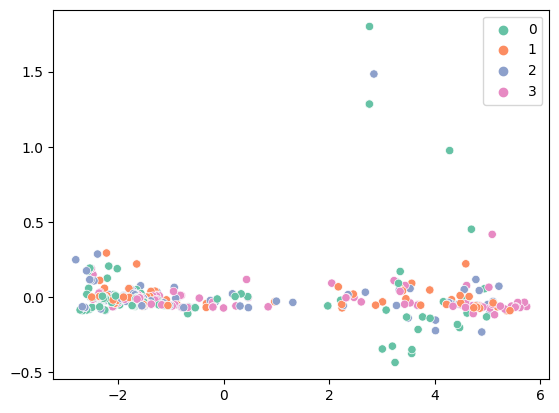

In [315]:
test_auc = trainer.test(model=model, datamodule=datamodule, verbose=False)[0]["test/auc"]
z, y = trainer.predict(model=model, datamodule=datamodule)[0]

visualize_embeddings(z=z, y=y)


In [316]:
print(f'{test_auc * 100.:.2f}[%]')

57.24[%]


/usr/local/lib/python3.10/dist-packages/ipykernel/ipkernel.py:283: DeprecationWarning: `should_run_async` will not call `transform_cell` automatically in the future. Please pass the result to `transformed_cell` argument and any exception that happen during thetransform in `preprocessing_exc_tuple` in IPython 7.17 and above.
  and should_run_async(code)


### totalnie randomowe

In [66]:
import random


labels = data.y.unique()

def random_node_classification(nodes, labels=labels):
    node_labels = {}

    for node in nodes:
        node_labels[node] = random.choice(labels)

    return node_labels



In [67]:
from sklearn import metrics

n = 1000
auc_rand = 0

for _ in range(n):
    _, rand_test = train_test_split(df_to_split, test_size=0.2, random_state=42, stratify=df_to_split['label'])

    y_true = np.array(rand_test['label'])

    rand_test_nodes = rand_test['node']
    y_rand = random_node_classification(rand_test_nodes)
    y_rand = np.array([tensor.item() for _, tensor in y_rand.items()])

    fpr, tpr, thresholds = metrics.roc_curve(y_true, y_rand, pos_label=2)
    auc_rand += metrics.auc(fpr, tpr)

print(f"AUC totalnie randomowej klasyfikacji: {auc_rand/n}")

AUC totalnie randomowej klasyfikacji: 0.4983943001443005
